# Soil aggregate-size analysis

This notebook analyzes aggregate areas measured from photographs of soil samples.

**Primary question:** does soil under *Arachis pintoi* (+COVER) show a systematic shift toward larger aggregates than soil without *A. pintoi* (-COVER)?

The individual detected aggregates within a photograph are **not treated as independent experimental replicates**. Instead, each photograph is the independent sampling unit. The complete aggregate-size distribution within each photograph is retained, and between-photograph distributional differences are summarized using the Mann–Whitney probability-of-superiority effect size.

For every +COVER / -COVER photograph pair,

\[
A = U/(n_+n_-)
\]

where \(U\) is the Mann–Whitney statistic. \(A=0.5\) indicates no stochastic shift, while \(A>0.5\) means that an aggregate selected at random from the +COVER photograph is more likely to be larger than one selected from the -COVER photograph.

Statistical significance is assessed by an **exact permutation test at the photograph level**, evaluating every possible assignment of the 13 labeled photographs into groups of 10 +COVER and 3 -COVER photographs.

## 1. Imports and input file

Place this notebook in the same directory as `Juntos-todos(1).csv`, or change `INPUT_CSV` below.

In [1]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

INPUT_CSV = Path("soil-aggregate-image-analysis.csv")

if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {INPUT_CSV}. Put the CSV beside this notebook "
        "or change INPUT_CSV to the correct path."
    )

raw = pd.read_csv(INPUT_CSV)
print("Rows:", len(raw))
print("Columns:", raw.columns.tolist())
raw.head()

Rows: 48281
Columns: ['Source.Name', ' ', 'Label', 'Micorriza', 'Café', 'Arachis', 'Area', 'X', 'Y', 'Perim.']


,Source.Name,,Label,Micorriza,Café,Arachis,Area,X,Y,Perim.
0,14CAFECARBON1.csv,1,14 CAFE CARBON.jpg,NO,C,NO,87,369.67,15.58,36.04
1,14CAFECARBON1.csv,2,14 CAFE CARBON.jpg,NO,C,NO,45,158.57,32.59,26.38
2,14CAFECARBON1.csv,3,14 CAFE CARBON.jpg,NO,C,NO,56,310.12,32.93,26.14
3,14CAFECARBON1.csv,4,14 CAFE CARBON.jpg,NO,C,NO,475,140.35,44.40,120.85
4,14CAFECARBON1.csv,5,14 CAFE CARBON.jpg,NO,C,NO,374,260.58,46.29,101.78


## 2. Clean treatment labels and inspect replication

Only photographs with an explicit `Arachis` label (`A` or `NO`) are used for the COVER inference. Rows lacking a COVER label are retained in the original CSV but excluded here rather than inferred from filenames.

In [12]:
# ============================================================
# Pairwise Mann-Whitney probability-of-superiority effect sizes
#
# Display photographs using generic identifiers rather than
# idiosyncratic source filenames.
# ============================================================

photo_values = {
    name: g["Area"].dropna().to_numpy()
    for name, g in labeled.groupby("Source.Name")
}

photo_cover = (
    labeled.groupby("Source.Name")["COVER"]
    .first()
)

cover_photos = sorted(
    photo_cover[photo_cover == "+COVER"].index
)

no_cover_photos = sorted(
    photo_cover[photo_cover == "-COVER"].index
)


def probability_superiority(x, y):
    """
    Probability that an aggregate randomly selected from X
    is larger than one randomly selected from Y.

    Ties contribute one half through the Mann-Whitney U statistic.
    """
    result = stats.mannwhitneyu(
        x,
        y,
        alternative="two-sided",
        method="asymptotic"
    )

    return result.statistic / (len(x) * len(y))


# ------------------------------------------------------------
# Compute using original photograph identifiers
# ------------------------------------------------------------

pairwise_A = pd.DataFrame(
    index=cover_photos,
    columns=no_cover_photos,
    dtype=float
)

for cover_photo in cover_photos:

    for no_cover_photo in no_cover_photos:

        pairwise_A.loc[
            cover_photo,
            no_cover_photo
        ] = probability_superiority(
            photo_values[cover_photo],
            photo_values[no_cover_photo]
        )


# ------------------------------------------------------------
# Generic names for presentation
# ------------------------------------------------------------

cover_labels = {
    name: f"+COVER{i+1}"
    for i, name in enumerate(cover_photos)
}

no_cover_labels = {
    name: f"-COVER{i+1}"
    for i, name in enumerate(no_cover_photos)
}


pairwise_A_display = pairwise_A.rename(
    index=cover_labels,
    columns=no_cover_labels
)


display(pairwise_A_display.round(3))


# ------------------------------------------------------------
# Keep the mapping for reproducibility
# ------------------------------------------------------------

photo_name_mapping = pd.DataFrame(
    [
        {
            "Display name": cover_labels[name],
            "Source.Name": name
        }
        for name in cover_photos
    ]
    +
    [
        {
            "Display name": no_cover_labels[name],
            "Source.Name": name
        }
        for name in no_cover_photos
    ]
)

print("Photograph-name mapping (for reproducibility):")
display(photo_name_mapping)


# ------------------------------------------------------------
# Overall result
# ------------------------------------------------------------

pairwise_values = pairwise_A.to_numpy().ravel()

observed_A = pairwise_values.mean()

n_above_half = int(
    (pairwise_values > 0.5).sum()
)

print(
    f"Mean probability-of-superiority A = "
    f"{observed_A:.3f}"
)

print(
    f"A > 0.5 in {n_above_half} of "
    f"{len(pairwise_values)} photograph pairs"
)

,-COVER1,-COVER2,-COVER3
+COVER1,0.608,0.611,0.592
+COVER2,0.520,0.530,0.500
+COVER3,0.589,0.594,0.573
+COVER4,0.572,0.579,0.555
+COVER5,0.585,0.594,0.566
+COVER6,0.667,0.669,0.653
+COVER7,0.568,0.578,0.549
+COVER8,0.573,0.582,0.553
+COVER9,0.621,0.628,0.604
+COVER10,0.511,0.525,0.489


Photograph-name mapping (for reproducibility):


,Display name,Source.Name
0,+COVER1,F10A720LIMPNC1.csv
1,+COVER2,F1A0D12CAFE1.csv
2,+COVER3,F1A0P11LIMON1.csv
3,+COVER4,F2A5M1.csv
4,+COVER5,F3A51.csv
5,+COVER6,F3A5J26CAFE1.csv
6,+COVER7,F5A5LLIMON71.csv
7,+COVER8,F6A58LIMON1.csv
8,+COVER9,F9A812222CAFE1.csv
9,+COVER10,F9A923LIMONC1.csv


Mean probability-of-superiority A = 0.578
A > 0.5 in 28 of 30 photograph pairs


### Missing treatment metadata

This check makes the excluded photographs explicit. Their treatment status should not be reconstructed from filenames unless supported by the experimental records.

In [3]:
all_photos = set(df["Source.Name"].dropna().unique())
labeled_photos = set(labeled["Source.Name"].dropna().unique())
unlabeled_photos = sorted(all_photos - labeled_photos)

print("Photographs excluded because COVER is missing:", len(unlabeled_photos))
for name in unlabeled_photos:
    print("  ", name)

Photographs excluded because COVER is missing: 11
   15CAFE1.csv
   16CAFECIZ1.csv
   19CAFE1.csv
   21CAFEC1.csv
   26CAFE1.csv
   F5A824LIMONC1.csv
   F8A41.csv
   F8A421.csv
   F8A71.csv
   F9A4J2111.csv
   SINNOMBRE1.csv


## 3. Four treatment histograms

These preserve the visual presentation of the original figure. The panels are **normalized to probability density** so differences in the number of detected aggregates do not simply change histogram height. All four panels use identical log-spaced bins and identical axes.

The plots are descriptive: inferential statistics below operate at the photograph level.

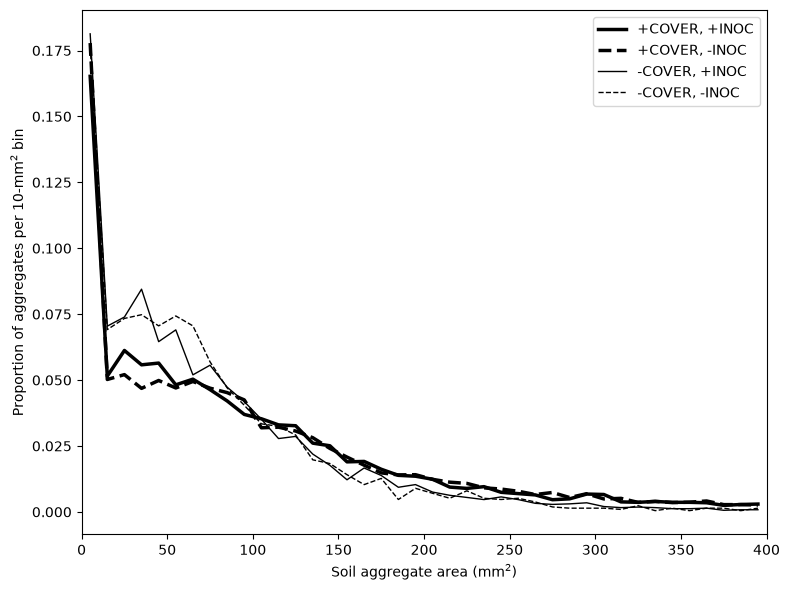

In [11]:
# ============================================================
# Four treatment distributions in one panel
# ============================================================

plot_df = labeled.dropna(subset=["INOC"]).copy()

BIN_WIDTH = 10
XMAX = 400

bins = np.arange(0, XMAX + BIN_WIDTH, BIN_WIDTH)
bin_centers = (bins[:-1] + bins[1:]) / 2

# COVER is represented by line thickness.
# INOC is represented by line style.
styles = [
    ("+COVER", "+INOC", "-",  2.5, "+COVER, +INOC"),
    ("+COVER", "-INOC", "--", 2.5, "+COVER, -INOC"),
    ("-COVER", "+INOC", "-",  1.0, "-COVER, +INOC"),
    ("-COVER", "-INOC", "--", 1.0, "-COVER, -INOC"),
]

fig, ax = plt.subplots(figsize=(8, 6))

for cover, inoc, linestyle, linewidth, label in styles:

    vals = plot_df.loc[
        (plot_df["COVER"] == cover) &
        (plot_df["INOC"] == inoc),
        "Area"
    ].dropna().to_numpy()

    # Histogram counts within displayed range
    counts, _ = np.histogram(vals, bins=bins)

    # Normalize by ALL aggregates in this treatment,
    # including aggregates > XMAX.
    #
    # Thus the plotted value is the fraction of all detected
    # aggregates falling into each displayed 10-mm2 interval.
    normalized_counts = counts / len(vals)

    ax.plot(
        bin_centers,
        normalized_counts,
        linestyle=linestyle,
        linewidth=linewidth,
        color="black",
        label=label
    )

ax.set_xlim(0, XMAX)

ax.set_xlabel(r"Soil aggregate area (mm$^2$)")
ax.set_ylabel(r"Proportion of aggregates per 10-mm$^2$ bin")

ax.legend(
    loc="upper right",
    frameon=True
)

ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)

fig.tight_layout()

plt.show()

fig.savefig(
    "soil-aggregate-distributions.png",
    dpi=300,
    bbox_inches="tight"
)


## 4. Optional ECDF view of COVER

An ECDF avoids histogram-bin choices. The thin lines show individual photographs; the treatment-level patterns should therefore be interpreted in conjunction with the photograph-level test below.

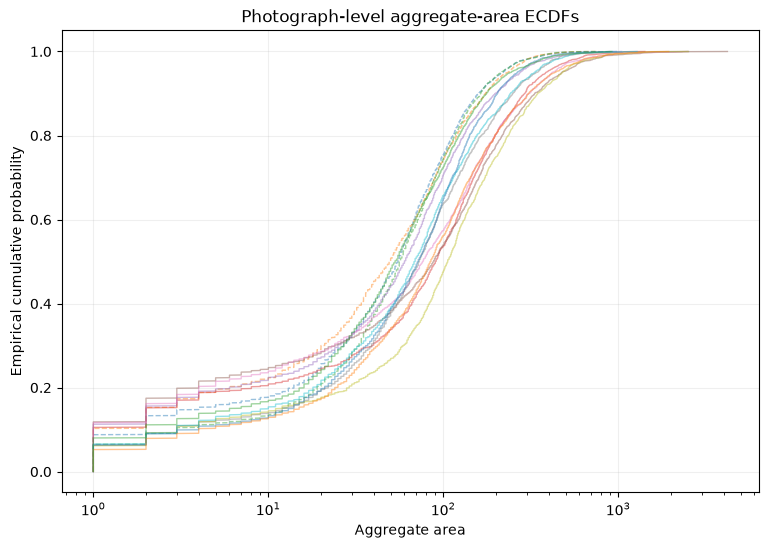

In [5]:
def ecdf(values):
    x = np.sort(np.asarray(values))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

fig, ax = plt.subplots(figsize=(9, 6))

for cover, linestyle, linewidth in [
    ("-COVER", "--", 1.0),
    ("+COVER", "-", 1.0),
]:
    for name, g in labeled.loc[labeled["COVER"] == cover].groupby("Source.Name"):
        x, y = ecdf(g["Area"])
        ax.plot(x, y, linestyle=linestyle, linewidth=linewidth, alpha=0.45)

ax.set_xscale("log")
ax.set_xlabel("Aggregate area")
ax.set_ylabel("Empirical cumulative probability")
ax.set_title("Photograph-level aggregate-area ECDFs")
ax.grid(alpha=0.2)
plt.show()

## 5. Pairwise Mann–Whitney probability-of-superiority effect sizes

There are 10 +COVER photographs and 3 -COVER photographs, giving 30 between-treatment photograph pairs.

For each pair we compute \(A=U/(n_+n_-)\). Values greater than 0.5 indicate a shift toward larger aggregates in the +COVER photograph.

In [6]:
photo_values = {
    name: g["Area"].dropna().to_numpy()
    for name, g in labeled.groupby("Source.Name")
}

photo_cover = (
    labeled.groupby("Source.Name")["COVER"]
    .first()
)

cover_photos = sorted(photo_cover[photo_cover == "+COVER"].index)
no_cover_photos = sorted(photo_cover[photo_cover == "-COVER"].index)

print("+COVER photographs:", len(cover_photos))
print("-COVER photographs:", len(no_cover_photos))
print("Pairwise comparisons:", len(cover_photos) * len(no_cover_photos))


def probability_superiority(x, y):
    """Mann-Whitney probability that X > Y, with ties contributing one half."""
    result = stats.mannwhitneyu(x, y, alternative="two-sided", method="asymptotic")
    return result.statistic / (len(x) * len(y))

pairwise_A = pd.DataFrame(
    index=cover_photos,
    columns=no_cover_photos,
    dtype=float
)

for cover_photo in cover_photos:
    for no_cover_photo in no_cover_photos:
        pairwise_A.loc[cover_photo, no_cover_photo] = probability_superiority(
            photo_values[cover_photo],
            photo_values[no_cover_photo]
        )

display(pairwise_A.round(3))

pairwise_values = pairwise_A.to_numpy().ravel()
observed_A = pairwise_values.mean()
n_above_half = int((pairwise_values > 0.5).sum())

print(f"Mean probability-of-superiority A = {observed_A:.6f}")
print(f"A > 0.5 in {n_above_half} of {len(pairwise_values)} photograph pairs")

+COVER photographs: 10
-COVER photographs: 3
Pairwise comparisons: 30


,14CAFECARBON1.csv,F10A3I12LIMON1.csv,F10A3S513CAFE1.csv
F10A720LIMPNC1.csv,0.608,0.611,0.592
F1A0D12CAFE1.csv,0.520,0.530,0.500
F1A0P11LIMON1.csv,0.589,0.594,0.573
F2A5M1.csv,0.572,0.579,0.555
F3A51.csv,0.585,0.594,0.566
F3A5J26CAFE1.csv,0.667,0.669,0.653
F5A5LLIMON71.csv,0.568,0.578,0.549
F6A58LIMON1.csv,0.573,0.582,0.553
F9A812222CAFE1.csv,0.621,0.628,0.604
F9A923LIMONC1.csv,0.511,0.525,0.489


Mean probability-of-superiority A = 0.577846
A > 0.5 in 28 of 30 photograph pairs


## 6. Visualize the 30 pairwise effect sizes

The dashed reference at 0.5 represents no stochastic dominance. Each point is one +COVER / -COVER photograph pair; these 30 points are **not independent tests**, so this panel is descriptive rather than inferential.

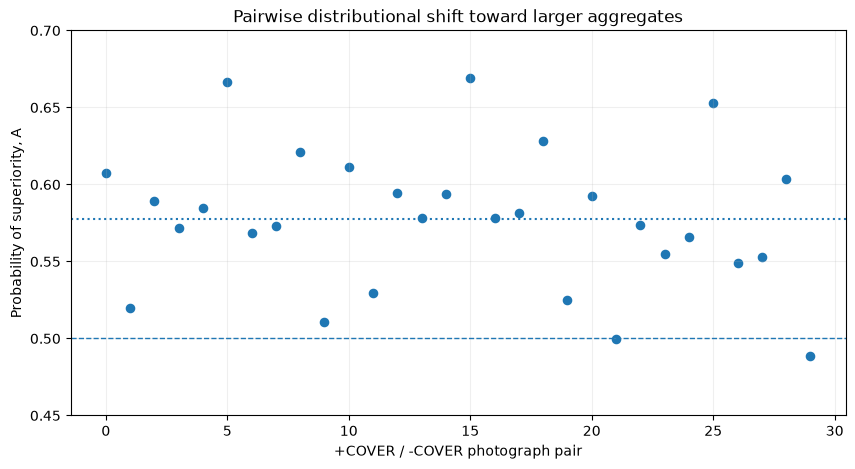

In [7]:
pair_long = (
    pairwise_A
    .reset_index(names="cover_photo")
    .melt(id_vars="cover_photo", var_name="no_cover_photo", value_name="A")
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(pair_long))
ax.scatter(x, pair_long["A"], s=35)
ax.axhline(0.5, linestyle="--", linewidth=1)
ax.axhline(observed_A, linestyle=":", linewidth=1.5)
ax.set_ylim(0.45, max(0.70, pair_long["A"].max() + 0.02))
ax.set_ylabel("Probability of superiority, A")
ax.set_xlabel("+COVER / -COVER photograph pair")
ax.set_title("Pairwise distributional shift toward larger aggregates")
ax.grid(alpha=0.2)
plt.show()

## 7. Exact photograph-level permutation test

The experimental unit is the photograph. Under the null hypothesis that COVER labels are exchangeable among photographs, there are

\[
{13 \choose 3}=286
\]

possible assignments of three photographs to the -COVER group and ten to the +COVER group.

For each assignment we recompute the **mean pairwise probability of superiority**. The one-sided permutation P-value is the fraction of assignments whose statistic is at least as large as the observed statistic. This tests the directional hypothesis that +COVER shifts aggregate sizes upward.

In [8]:
all_photos_labeled = sorted(photo_cover.index)
n_no_cover = len(no_cover_photos)

permutation_rows = []

for perm_no_cover_tuple in combinations(all_photos_labeled, n_no_cover):
    perm_no_cover = set(perm_no_cover_tuple)
    perm_cover = [p for p in all_photos_labeled if p not in perm_no_cover]

    vals = [
        probability_superiority(photo_values[p_cover], photo_values[p_no])
        for p_cover in perm_cover
        for p_no in perm_no_cover
    ]

    permutation_rows.append({
        "no_cover_photos": tuple(sorted(perm_no_cover)),
        "mean_A": float(np.mean(vals))
    })

permutation_df = pd.DataFrame(permutation_rows)

n_extreme = int((permutation_df["mean_A"] >= observed_A - 1e-15).sum())
p_exact_one_sided = n_extreme / len(permutation_df)

# Optional two-sided analogue, centered on the null value A=0.5.
n_extreme_two = int(
    (np.abs(permutation_df["mean_A"] - 0.5) >= abs(observed_A - 0.5) - 1e-15).sum()
)
p_exact_two_sided = n_extreme_two / len(permutation_df)

print("Observed mean A:", observed_A)
print("Exact assignments:", len(permutation_df))
print("Assignments with mean A >= observed:", n_extreme)
print("Exact one-sided permutation p:", p_exact_one_sided)
print("Exact two-sided permutation p:", p_exact_two_sided)

Observed mean A: 0.5778455436696412
Exact assignments: 286
Assignments with mean A >= observed: 2
Exact one-sided permutation p: 0.006993006993006993
Exact two-sided permutation p: 0.013986013986013986


## 8. Permutation null distribution

This graph shows where the actual treatment assignment lies among all 286 possible photograph-level assignments.

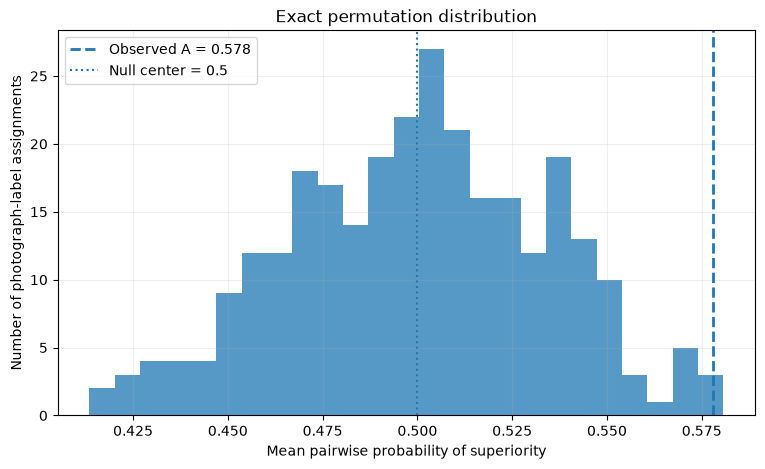

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(permutation_df["mean_A"], bins=25, alpha=0.75)
ax.axvline(observed_A, linestyle="--", linewidth=2, label=f"Observed A = {observed_A:.3f}")
ax.axvline(0.5, linestyle=":", linewidth=1.5, label="Null center = 0.5")
ax.set_xlabel("Mean pairwise probability of superiority")
ax.set_ylabel("Number of photograph-label assignments")
ax.set_title("Exact permutation distribution")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 9. Secondary photograph-level median analysis

This is not the primary distributional test, but it provides a simple photograph-level summary that is useful as a robustness check.

In [10]:
median_by_photo = (
    labeled.groupby(["Source.Name", "COVER"])["Area"]
    .median()
    .reset_index(name="median_area")
)

cover_medians = median_by_photo.loc[
    median_by_photo["COVER"] == "+COVER", "median_area"
].to_numpy()

no_cover_medians = median_by_photo.loc[
    median_by_photo["COVER"] == "-COVER", "median_area"
].to_numpy()

mw_medians = stats.mannwhitneyu(
    cover_medians,
    no_cover_medians,
    alternative="two-sided",
    method="exact"
)

print("+COVER photograph medians:", np.sort(cover_medians))
print("-COVER photograph medians:", np.sort(no_cover_medians))
print("Median of photograph medians, +COVER:", np.median(cover_medians))
print("Median of photograph medians, -COVER:", np.median(no_cover_medians))
print("Exact two-sided Mann-Whitney p on photograph medians:", mw_medians.pvalue)

+COVER photograph medians: [ 53.   60.   69.   72.   73.   76.   85.   88.   90.5 106. ]
-COVER photograph medians: [49. 55. 56.]
Median of photograph medians, +COVER: 74.5
Median of photograph medians, -COVER: 55.0
Exact two-sided Mann-Whitney p on photograph medians: 0.027972027972027972


## 10. Reproducible result summary

With the current labeled dataset, the expected primary result is approximately:

- 10 +COVER photographs and 3 -COVER photographs
- 30 between-treatment photograph pairs
- mean probability-of-superiority \(A pprox 0.578\)
- 28/30 pairwise comparisons with \(A>0.5\)
- exact one-sided photograph-level permutation \(P = 2/286 pprox 0.007\)

The inferential P-value comes from permuting **whole photographs**, not individual aggregates. This preserves the photograph as the independent experimental unit while allowing each photograph's full aggregate-size distribution to contribute to the effect statistic.

### Methods 

> Aggregate-size distributions were compared between every pair of COVER and no-COVER soil photographs using the Mann–Whitney U statistic, expressed as the probability-of-superiority effect size, A = U/(n1 n2). Effect sizes were averaged across all between-treatment photograph pairs. Statistical significance was assessed by an exact permutation test at the photograph level, evaluating all possible assignments of the labeled photographs to groups with the observed treatment sizes.

### Results 

> Aggregate sizes were consistently greater in soils with *A. pintoi* cover: 28 of 30 pairwise photograph comparisons showed a shift toward larger aggregates under *A. pintoi*. Across comparisons, the mean probability that an aggregate from an *A. pintoi* sample was larger than one from a no-COVER sample was 0.578. The distributional shift was significant in an exact photograph-level permutation test (P = 0.007).

## 11. Export analysis tables

These CSVs make the numerical results easy to archive alongside the notebook and manuscript.

In [ ]:
photo_summary.to_csv("aggregate_photo_summary.csv", index=False)
pairwise_A.to_csv("aggregate_pairwise_probability_superiority.csv")
permutation_df.to_csv("aggregate_exact_permutation_distribution.csv", index=False)

print("Wrote:")
print("  aggregate_photo_summary.csv")
print("  aggregate_pairwise_probability_superiority.csv")
print("  aggregate_exact_permutation_distribution.csv")